In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install keras-cv -q

In [4]:
import tensorflow as tf
tf.__version__

E0000 00:00:1755692704.928133  178007 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755692704.934691  178007 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.18.0'

In [5]:
import keras
tf.__version__

'2.18.0'

In [6]:
import cv2
import math
import time
import shutil 
import random
import numpy as np
import pandas as pd 
from glob import glob
import matplotlib.pyplot as plt
import albumentations as A
from functools import partial

In [7]:
import keras_cv
from keras import ops
from keras import layers
import tensorflow_datasets as tfds

tfds.disable_progress_bar()
keras.utils.set_random_seed(42)

In [8]:
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.random import gamma as tf_random_gamma

In [9]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [10]:
keras.saving.get_custom_objects().clear()
tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.config.optimizer.set_jit(True) ## enabling XLA
# policy = tf.keras.mixed_precision.Policy('mixed_float16')
# tf.keras.mixed_precision.set_global_policy(policy)

In [11]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [12]:
!nvidia-smi

Wed Aug 20 17:55:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN Xp                Off |   00000000:03:00.0  On |                  N/A |
| 32%   54C    P8             13W /  250W |     370MiB /  12288MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Variables

In [13]:
# transform_list = ['AutoContrast', 'BoxBlur', 'CLAHE', 'ChannelShuffle', 'ChromaticAberration', 'CoarseDropout', 
#                   'ColorJitter', 'Defocus', 'Dilation', 'ElasticTransform', 'Emboss', 'Equalize', 'EqualizeYUV', 
#                   'Erosion', 'Frost', 'Gamma', 'GaussNoise', 'GaussianBlur', 'GlassBlur', 'HorizontalFlip', 
#                   'HueSaturationValue', 'Invert', 'JPEGCompression', 'MedianBlur', 'MotionBlur', 'OpticalDistortion', 
#                   'Original', 'Perspective', 'Posterize', 'RGBShift', 'RandomBrightnessContrast', 'RandomFog', 
#                   'RandomGravel', 'RandomGridShuffle', 'RandomRain', 'RandomShadow', 'RandomSnow', 'RandomSunFlare', 
#                   'RandomToneCurve', 'Rotate', 'SaltandPepper', 'Scale', 'Sharpen', 'ShearX', 'ShearY', 'ShiftScaleRotate', 
#                   'Solarize', 'Speckle', 'ToGray', 'ToSepia', 'Translate', 'VerticalFlip', 'Vignette', 'ZoomBlur']

In [14]:
transform_list = ['Original']

In [15]:
print(len(transform_list))

1


In [16]:
threshold = 0.50
end = '_ISIC2019_classification_Sel_Aug_Th_'+str(threshold)
destination='Results/classification2/2.ISIC2019/Fold1/'

In [17]:
tempfolder="temp_ISIC2019_sel_aug_1"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

data_root="Datasets/2.ISIC2019/classification/fold1/"
output_path="./"+tempfolder+"/"

train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [18]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  8
num_train_images :  17064
num_test_images :  4261


In [19]:
EPOCHS=40
IMG_SIZE=224
BATCH_SIZE=64
LEARNING_RATE=0.0001
dropout_rate=0.3
BUFFER_SIZE=num_train_images
AUTOTUNE = tf.data.AUTOTUNE

In [20]:
classes=sorted(os.listdir(train_dir))
print(classes)

['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [21]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")    
    # image = tf.image.decode_png(image, channels=3)
    # image = tf.image.decode_bmp(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE), method="area")
    return image, label

In [22]:
file_names_train = glob(train_dir + '*/*')
random.shuffle(file_names_train)    
lbls_train = [classes.index(name.split('/')[-2]) for name in file_names_train]
lbls_train_onehot = keras.ops.one_hot(lbls_train, num_classes)
train_ds = tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train_onehot))
train_ds = train_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)

I0000 00:00:1755692711.965958  178007 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11159 MB memory:  -> device: 0, name: NVIDIA TITAN Xp, pci bus id: 0000:03:00.0, compute capability: 6.1


In [23]:
file_names_test=glob(test_dir + '*/*')     
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
lbls_test_onehot = keras.ops.one_hot(lbls_test, num_classes)
test_ds=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test_onehot))
test_ds=test_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
test_ds=test_ds.batch(BATCH_SIZE)

In [24]:
train_ds_mixup = tf_data.Dataset.zip((train_ds, train_ds))

In [25]:
def sample_beta_distribution(size, concentration_0=0.2, concentration_1=0.2):
    gamma_1_sample = tf_random_gamma(shape=[size], alpha=concentration_1)
    gamma_2_sample = tf_random_gamma(shape=[size], alpha=concentration_0)
    return gamma_1_sample / (gamma_1_sample + gamma_2_sample)

In [26]:
def mix_up(ds_one, ds_two, alpha=0.2):
    images_one, labels_one = ds_one
    images_two, labels_two = ds_two
    batch_size = keras.ops.shape(images_one)[0]

    l = sample_beta_distribution(batch_size, alpha, alpha)
    x_l = keras.ops.reshape(l, (batch_size, 1, 1, 1))
    x_l = tf.cast(x_l, tf.float32)
    y_l = keras.ops.reshape(l, (batch_size, 1))

    images_one = tf.cast(images_one, tf.float32)
    images_two = tf.cast(images_two, tf.float32)
    labels_one = tf.cast(labels_one, tf.float32)
    labels_two = tf.cast(labels_two, tf.float32)

    images = images_one * x_l + images_two * (1 - x_l)
    labels = labels_one * y_l + labels_two * (1 - y_l)    

    return (images, labels)

In [27]:
# First create the new dataset using our `mix_up` utility
train_ds_mu = train_ds_mixup.map(
    lambda ds_one, ds_two: mix_up(ds_one, ds_two, alpha=0.2),
    num_parallel_calls=AUTOTUNE,
)

In [28]:
# # Let's preview 9 samples from the dataset
# sample_images, sample_labels = next(iter(train_ds_mu))
# plt.figure(figsize=(10, 10))
# for i, (image, label) in enumerate(zip(sample_images[:9], sample_labels[:9])):
#     ax = plt.subplot(3, 3, i + 1)
#     plt.imshow(image.numpy().squeeze())
#     print(label.numpy().tolist())
#     plt.axis("off")

In [29]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 484, 2123, 1639,  115, 2972, 9270,  338,  123]))


In [30]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {np.int64(0): np.float64(4.407), np.int64(1): np.float64(1.0047), np.int64(2): np.float64(1.3014), np.int64(3): np.float64(18.5478), np.int64(4): np.float64(0.7177), np.int64(5): np.float64(0.2301), np.int64(6): np.float64(6.3107), np.int64(7): np.float64(17.3415)}


# Prepare Model

In [31]:
@keras.saving.register_keras_serializable('SpatialAttention')
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [32]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=True

x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x) 
model = tf.keras.Model(base_model.input, output, name="EfficientNetB0")
# model = tf.keras.models.load_model(weights, custom_objects={'SpatialAttention': SpatialAttention})

In [33]:
# till=model.layers.index(model.get_layer('block5a_expand_conv'))+1    
# for layer in model.layers[:till]:
#     layer.trainable=False
# for layer in model.layers[till:]:
#     layer.trainable=True
    # if isinstance(layer, tf.keras.layers.BatchNormalization):
    #     layer.trainable = False

In [34]:
# i=1
# j=len(model.layers)
# for x in model.layers:
#     print(i, j, x.name, x.output.shape, x.trainable)
#     i=i+1
#     j=j-1

# Model Information

In [35]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,838
Trainable params: 4,733,975
Non-trainable params: 45,863


In [36]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [37]:
flops = get_flops(model)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [38]:
print(macs/10 ** 9)

0.401186798
lock7a_bn_1/batchnorm/mul (1.15k/1.15k flops)
  block7a_bn_1/batchnorm/mul_2 (1.15k/1.15k flops)
  block7a_bn_1/batchnorm/sub (1.15k/1.15k flops)
  block7a_expand_bn_1/batchnorm/add (1.15k/1.15k flops)
  block7a_expand_bn_1/batchnorm/mul (1.15k/1.15k flops)
  block7a_expand_bn_1/batchnorm/mul_2 (1.15k/1.15k flops)
  block7a_expand_bn_1/batchnorm/sub (1.15k/1.15k flops)
  block7a_se_expand_1/BiasAdd (1.15k/1.15k flops)
  batch_normalization_1_2/batchnorm/Rsqrt (1.02k/1.02k flops)
  block4b_bn_1/batchnorm/Rsqrt (960/960 flops)
  block4b_expand_bn_1/batchnorm/Rsqrt (960/960 flops)
  block4c_bn_1/batchnorm/Rsqrt (960/960 flops)
  block4c_expand_bn_1/batchnorm/Rsqrt (960/960 flops)
  block5a_bn_1/batchnorm/Rsqrt (960/960 flops)
  block5a_expand_bn_1/batchnorm/Rsqrt (960/960 flops)
  block2a_se_expand_1/convolution (768/768 flops)
  block2a_se_reduce_1/convolution (768/768 flops)
  block5b_bn_1/batchnorm/add (672/672 flops)
  block5b_bn_1/batchnorm/mul (672/672 flops)
  block5b_b

In [39]:
print(flops/10 ** 9)

0.802373596


# Train Model

In [40]:
regularizer=tf.keras.regularizers.l2(0.00001)
for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

In [41]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5) #, label_smoothing=0.05)
model.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [42]:
def warmup_gpu(model, input_shape, dtype=tf.float32, steps=10):
    dummy_input = tf.random.normal([1, *input_shape], dtype=dtype)

    for i in range(steps):
        _ = model(dummy_input, training=False)
    print(f"[Warmup] GPU warmed up with {steps} dummy passes.")

# Example usage:
warmup_gpu(model, input_shape=(224, 224, 3))

I0000 00:00:1755692719.962120  178007 cuda_dnn.cc:529] Loaded cuDNN version 90800


[Warmup] GPU warmed up with 10 dummy passes.


In [43]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [44]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60     
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [45]:
%%time
t1=time.time()
history = model.fit(
    train_ds_mu,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    validation_data=test_ds,
    callbacks=[ModelCheckPoint] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/40


I0000 00:00:1755692768.199046  178163 service.cc:148] XLA service 0x794a84003890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755692768.199091  178163 service.cc:156]   StreamExecutor device (0): NVIDIA TITAN Xp, Compute Capability 6.1
E0000 00:00:1755692788.270468  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692788.454475  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692789.023870  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692789.219920  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accur

266/267 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.1824 - loss: 0.4915

E0000 00:00:1755692889.587631  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692889.765068  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692890.256997  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692890.447954  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755692890.810794  178163 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.1826 - loss: 0.4913
Epoch 1: val_accuracy improved from -inf to 0.27740, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-001-0.2774.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 215s 436ms/step - accuracy: 0.1827 - loss: 0.4911 - val_accuracy: 0.2774 - val_loss: 0.2574
Epoch 2/40
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.3045 - loss: 0.2563
Epoch 2: val_accuracy improved from 0.27740 to 0.41023, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-002-0.4102.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 57s 211ms/step - accuracy: 0.3045 - loss: 0.2562 - val_accuracy: 0.4102 - val_loss: 0.2438
Epoch 3/40
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.3609 - loss: 0.1872
Epoch 3: val_accuracy improved from 0.41023 to 0.46069, saving model to ./temp_ISIC2019_sel_aug_1/EfficientNetB0-003-0.4607.weights.h5
267/267 ━━━━━━━━━━━━━━━━━━━━ 56s 211ms/step - accuracy: 0.3609 - loss: 0.1872 - val_accuracy: 0.4607 - v

In [46]:
for x in sorted(os.listdir(output_path))[:-3]:
    os.remove(output_path+x)

In [47]:
model.load_weights(output_path+sorted(os.listdir(output_path))[-1]) 

In [48]:
test_loss, test_accuracy_by_evaluate = model.evaluate(test_ds)

67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7679 - loss: 0.0725


In [49]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [50]:
Hist = {'hist' : history.history} 
df = pd.DataFrame.from_dict(Hist)  
df.to_csv(output_path+'Hist.csv', index = True, header=True)  

In [51]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [52]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [53]:
name=output_path+"{}".format(savedfilename)+".keras"
model.save(name)

In [54]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
model.save_weights(name_weights)

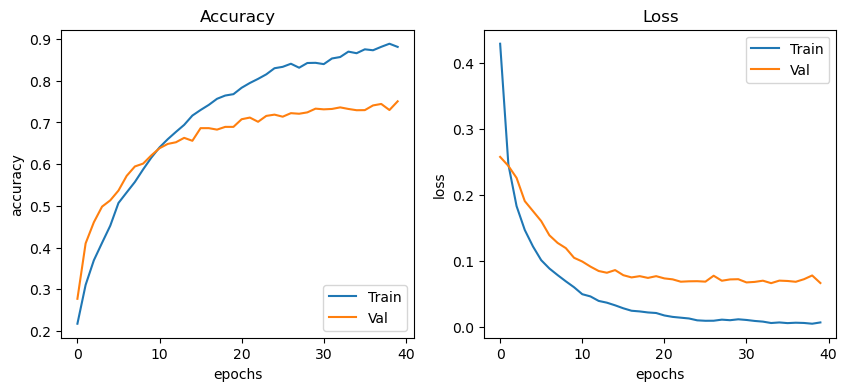

In [55]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [56]:
# predictions=model.predict(test_dataset)
# y_pred = np.argmax(predictions, axis=1)
# y_true = np.concatenate([y for x, y in test_dataset], axis=0)
# y_prob = predictions

# same = 0
# total = len(y_true)

# for i in range(total):
#     if y_true[i] == y_pred[i]:
#         same=same+1
        
# test_acc = same/total*100
# res='{:.2f}'.format(test_acc)
# print(same)
# print(total)
# print(res)

In [57]:
%%time
predi=model.predict(test_ds)
y_p = np.argmax(predi, axis=1)
y_t = np.concatenate([y for x, y in test_ds], axis=0)
y_tt = np.argmax(y_t, axis=1)
y_pr = predi

same = 0
total = len(y_tt)

for i in range(total):
    if y_tt[i] == y_p[i]:
        same=same+1
        
test_acc = same/total*100
res='{:.2f}'.format(test_acc)
print(same)
print(total)
print(res)

67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 135ms/step
3198
4261
75.05
CPU times: user 2min 55s, sys: 1.88 s, total: 2min 57s
Wall time: 17.6 s


In [58]:
y_pred = y_p
y_true = y_tt
y_prob = y_pr

In [59]:
%%time
tm = []
correctly_classified = {"y_true":[], "y_pred":[], "y_prob":[], "filename":[], "inference_time":[]}
mis_classified = {"orig":[],"pred":[], "prob":[], "filename":[], "inference_time":[]}
for i in file_names_test:
    image=tf.keras.utils.load_img(i)
    input_arr=tf.keras.utils.img_to_array(image)
    img_resized=tf.image.resize(input_arr, size=(IMG_SIZE, IMG_SIZE))
    input_img=np.array([img_resized])  
    start_time=time.time()  
    predictions=model(input_img, training=False)
    end_time=time.time()
    t=1000*(end_time-start_time)
    tm.append(t)
    pr_fnl = np.argmax(predictions, axis=1)[0]
    lbl=classes.index(i.split('/')[-2])
    
    if lbl == pr_fnl:
        correctly_classified["y_true"].append(lbl)
        correctly_classified["y_pred"].append(pr_fnl)
        correctly_classified["y_prob"].append(predictions)
        correctly_classified["filename"].append(i)
        correctly_classified["inference_time"].append(t)
    else:
        mis_classified["orig"].append(lbl)
        mis_classified["pred"].append(pr_fnl)
        mis_classified["prob"].append(predictions)
        mis_classified["filename"].append(i)
        mis_classified["inference_time"].append(t)

print(len(correctly_classified["y_true"]))
print(len(y_t))
test_acc1 = len(correctly_classified["y_true"])/len(y_t)*100
print('{:.2f}'.format(test_acc1))

3107
4261
72.92
CPU times: user 19min 13s, sys: 2.68 s, total: 19min 16s
Wall time: 19min 15s


In [60]:
# print(f"Average (ms) : {np.mean(tm)}")
# print(f"Std dev (ms) : {np.std(tm)}")
# print(f"Min     (ms) : {np.min(tm)}")
# print(f"Max     (ms) : {np.max(tm)}")

In [61]:
df11 = pd.DataFrame.from_dict(correctly_classified) 
df11.to_csv(output_path+'correctly_classified.csv', index = True, header=True)

df22 = pd.DataFrame.from_dict(mis_classified) 
df22.to_csv(output_path+'mis_classified.csv', index = True, header=True)

In [62]:
# y_pred1=correctly_classified["y_pred"]
# y_true1=correctly_classified["y_true"]  
# y_prob1=correctly_classified["y_prob"]

# y_pred2=mis_classified["pred"]
# y_true2=mis_classified["orig"]  
# y_prob2=mis_classified["prob"]

# y_pred=y_pred1+y_pred2
# y_true=y_true1+y_true2
# y_prob=y_prob1+y_prob2

In [63]:
y_test = tf.keras.utils.to_categorical(y_true)

In [64]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[  70   20   14    0    8    2    7    0]
 [  36  408   28    0   27   23    7    1]
 [  18   21  241    1   59   61    7    1]
 [   1    3    2   14    3    2    2    1]
 [  14   24   61    0  497  142    1    3]
 [   7   53   94    8  244 1905    0    6]
 [   7   18    8    1    9    2   39    0]
 [   0    0    2    0    2    2    0   24]]


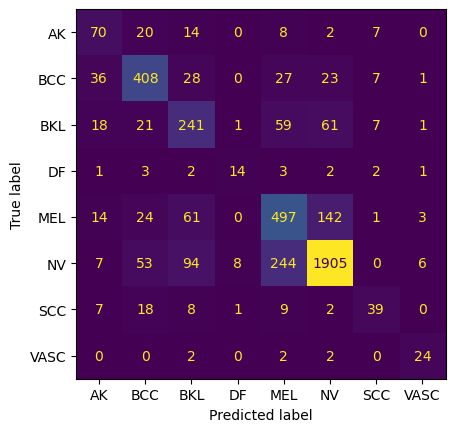

In [65]:
fig_path=output_path+"confusion_matrix.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [66]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred, normalize='all')
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[1.64280685e-02 4.69373387e-03 3.28561371e-03 0.00000000e+00
  1.87749355e-03 4.69373387e-04 1.64280685e-03 0.00000000e+00]
 [8.44872096e-03 9.57521709e-02 6.57122741e-03 0.00000000e+00
  6.33654072e-03 5.39779395e-03 1.64280685e-03 2.34686693e-04]
 [4.22436048e-03 4.92842056e-03 5.65594931e-02 2.34686693e-04
  1.38465149e-02 1.43158883e-02 1.64280685e-03 2.34686693e-04]
 [2.34686693e-04 7.04060080e-04 4.69373387e-04 3.28561371e-03
  7.04060080e-04 4.69373387e-04 4.69373387e-04 2.34686693e-04]
 [3.28561371e-03 5.63248064e-03 1.43158883e-02 0.00000000e+00
  1.16639287e-01 3.33255104e-02 2.34686693e-04 7.04060080e-04]
 [1.64280685e-03 1.24383947e-02 2.20605492e-02 1.87749355e-03
  5.72635532e-02 4.47078151e-01 0.00000000e+00 1.40812016e-03]
 [1.64280685e-03 4.22436048e-03 1.87749355e-03 2.34686693e-04
  2.11218024e-03 4.69373387e-04 9.15278104e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.69373387e-04 0.00000000e+00
  4.69373387e-04 4.69373387e-04 0.00000000e+0

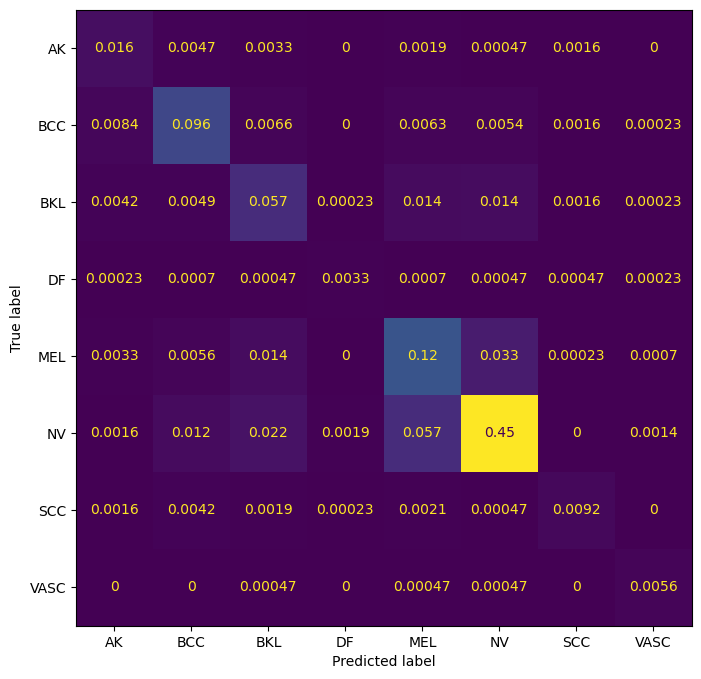

In [67]:
fig_path=output_path+"confusion_matrix1.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.set_figwidth(8)
fig.set_figheight(8)
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [68]:
y_prob = np.array(y_prob)
y_prob_new = y_prob.reshape(y_pr.shape)

In [69]:
from sklearn.metrics import roc_auc_score
targetnames=classes
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    r = roc_auc_score(y_test[:, i], y_prob_new[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of AK is: 0.9422186289775223
The ROC AUC score of BCC is: 0.970148121551711
The ROC AUC score of BKL is: 0.9050809029443951
The ROC AUC score of DF is: 0.8756032533495326
The ROC AUC score of MEL is: 0.8741966023488968
The ROC AUC score of NV is: 0.932926428562548
The ROC AUC score of SCC is: 0.9133377794498215
The ROC AUC score of VASC is: 0.9956905380918616


In [70]:
from sklearn.metrics import roc_curve, auc
fpr = {}
tpr = {}
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob_new[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

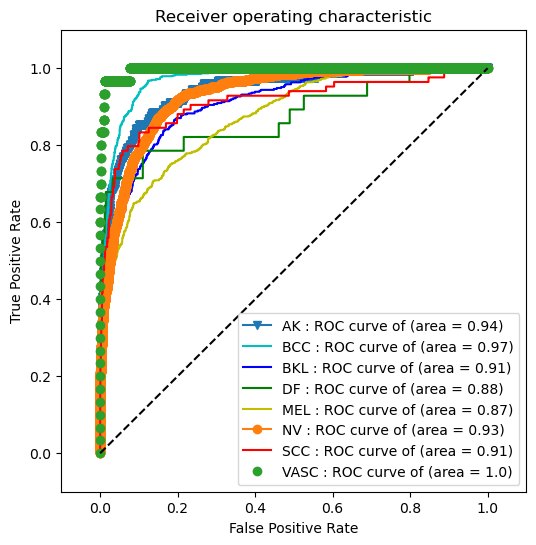

In [71]:
fig_path_roc=output_path+"roc_auc_curve.pdf"
fig = plt.figure(figsize=(6,6))
l0="{}".format(targetnames[0])+" : ROC curve of (area = {}".format(round(roc_auc[0],2))+")"
l1="{}".format(targetnames[1])+" : ROC curve of (area = {}".format(round(roc_auc[1],2))+")"
l2="{}".format(targetnames[2])+" : ROC curve of (area = {}".format(round(roc_auc[2],2))+")"
l3="{}".format(targetnames[3])+" : ROC curve of (area = {}".format(round(roc_auc[3],2))+")"
l4="{}".format(targetnames[4])+" : ROC curve of (area = {}".format(round(roc_auc[4],2))+")"
l5="{}".format(targetnames[5])+" : ROC curve of (area = {}".format(round(roc_auc[5],2))+")"
l6="{}".format(targetnames[6])+" : ROC curve of (area = {}".format(round(roc_auc[6],2))+")"
l7="{}".format(targetnames[7])+" : ROC curve of (area = {}".format(round(roc_auc[7],2))+")"
# l8="{}".format(targetnames[8])+" : ROC curve of (area = {}".format(round(roc_auc[8],2))+")"
plt.plot(fpr[0], tpr[0],'v-',label=l0)
plt.plot(fpr[1], tpr[1],'c' ,label=l1)
plt.plot(fpr[2], tpr[2],'b' ,label=l2)
plt.plot(fpr[3], tpr[3],'g' ,label=l3)
plt.plot(fpr[4], tpr[4],'y' ,label=l4)
plt.plot(fpr[5], tpr[5],'o-',label=l5)
plt.plot(fpr[6], tpr[6],'r' ,label=l6)
plt.plot(fpr[7], tpr[7],'o' ,label=l7)
# plt.plot(fpr[8], tpr[8],'c' ,label=l8)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
fig.savefig(fig_path_roc, format='pdf', bbox_inches='tight')

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_true, y_pred)
print('Accuracy: {}'.format(accuracy_score))

Accuracy: 0.7505280450598452


In [73]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_true, y_pred, 
    target_names=targetnames, zero_division=0)
print('Classification Report : \n')
print(classification_report)

Classification Report : 

              precision    recall  f1-score   support

          AK       0.46      0.58      0.51       121
         BCC       0.75      0.77      0.76       530
         BKL       0.54      0.59      0.56       409
          DF       0.58      0.50      0.54        28
         MEL       0.59      0.67      0.62       742
          NV       0.89      0.82      0.86      2317
         SCC       0.62      0.46      0.53        84
        VASC       0.67      0.80      0.73        30

    accuracy                           0.75      4261
   macro avg       0.64      0.65      0.64      4261
weighted avg       0.76      0.75      0.76      4261



In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [75]:
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Precision: {micro_precision}")
print(f"Macro Precision: {macro_precision}")
print(f"Weighted Precision: {weighted_precision}")

Micro Precision: 0.7505280450598452
Macro Precision: 0.6355004795458052
Weighted Precision: 0.7641269862762448


In [76]:
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Recall: {micro_recall}")
print(f"Macro Recall: {macro_recall}")
print(f"Weighted Recall: {weighted_recall}")

Micro Recall: 0.7505280450598452
Macro Recall: 0.6492308330895911
Weighted Recall: 0.7505280450598452


In [77]:
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro F1: {micro_f1}")
print(f"Macro F1: {macro_f1}")
print(f"Weighted F1: {weighted_f1}")

Micro F1: 0.7505280450598452
Macro F1: 0.6382330488271659
Weighted F1: 0.7554613555422203


In [78]:
from sklearn.metrics import roc_auc_score
micro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="micro")
macro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_true, y_prob_new, multi_class='ovr',average='weighted')

print(f"Micro-averaged One-vs-Rest ROC AUC score: {micro_roc_auc_ovr}")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr}")
print(f"Weighted One-vs-Rest ROC AUC score: {weighted_roc_auc_ovr}")

Micro-averaged One-vs-Rest ROC AUC score: 0.9613360773954494
Macro-averaged One-vs-Rest ROC AUC score: 0.9261502819095361
Weighted One-vs-Rest ROC AUC score: 0.9245992589686876


In [79]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score = balanced_accuracy_score(y_true, y_pred)
print('balanced_accuracy_score : ', balanced_accuracy_score)

balanced_accuracy_score :  0.6492308330895911


In [80]:
from sklearn.metrics import jaccard_score
jaccard_score = jaccard_score(y_true, y_pred, average='weighted')
print('jaccard_score : ', jaccard_score)

jaccard_score :  0.6217745985740057


In [81]:
specificity = []
cm = np.array(confusion_matrix(y_true, y_pred))
for i in range(cm.shape[0]):
    tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_i = np.round(specificity_i, 6)
    specificity.append(specificity_i)

print(f'Specificity for each class: {specificity}')
spec_unweighted=np.round(np.average(specificity), 6)
spec_weighted=np.round(np.average(specificity, weights=list(classWeight_dict.values())), 6)
print(spec_unweighted)
print(spec_weighted)

Specificity for each class: [np.float64(0.979952), np.float64(0.962745), np.float64(0.945742), np.float64(0.997638), np.float64(0.899972), np.float64(0.87963), np.float64(0.994254), np.float64(0.997164)]
0.957137
0.991474


In [82]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix = multilabel_confusion_matrix(y_true, y_pred)
print('multilabel_confusion_matrix : \n', multilabel_confusion_matrix)

multilabel_confusion_matrix : 
 [[[4057   83]
  [  51   70]]

 [[3592  139]
  [ 122  408]]

 [[3643  209]
  [ 168  241]]

 [[4223   10]
  [  14   14]]

 [[3167  352]
  [ 245  497]]

 [[1710  234]
  [ 412 1905]]

 [[4153   24]
  [  45   39]]

 [[4219   12]
  [   6   24]]]


# Saving All Results

In [83]:
import pandas as pd  
Labels={'File_Name':[],'True_Label':[],'Predicted_Label':[],'Prediction_Probability':[]}

for i in range(len(file_names_test)): 
    Labels['File_Name'].append(file_names_test[i])
    Labels['True_Label'].append(y_true[i])
    Labels['Predicted_Label'].append(y_pred[i])
    Labels['Prediction_Probability'].append(y_prob_new[i])

df = pd.DataFrame.from_dict(Labels) 
df.to_csv(output_path+'Labels.csv', index = False, header=True)

In [84]:
Class_Weights = {'classWeight' : classWeight}
df = pd.DataFrame.from_dict(Class_Weights) 
df.to_csv(output_path+'Class_Weights.csv', index = True, header=True)

In [85]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist) 
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [86]:
Hyperparameters = {
    'Number_of_Classes' : num_classes,
    'Number_of_Train_Images' : num_train_images,
    'Number_of_Test_Images' : num_test_images,
    'BATCH_SIZE' : BATCH_SIZE,
    'IMG_SIZE' : IMG_SIZE,
    'LEARNING_RATE' : LEARNING_RATE,
    'EPOCHS' : EPOCHS,
    'Number_of_Epoch_Actually_Executed' : len(history.history['loss']),            
}
df = pd.DataFrame.from_records([Hyperparameters]).transpose()
df.to_csv(output_path+'Hyperparameters.csv', index = True, header=False)

In [87]:
Results_in_Program = {
    'Time_Taken_for_execution_(in_seconds)' : time_taken,
    'Test_Accuracy_by_Model_Evaluate_Method' : test_accuracy_by_evaluate,        
    'Number_of_Correct_Predictions' : same,
    'Number_of_Total_Predictions' : total,
    'Test_Accuracy_by_Manual_Matching' : test_acc,
    'Test_Accuracy_Result_Adjusted' : res 
}
df = pd.DataFrame.from_records([Results_in_Program]).transpose()
df.to_csv(output_path+'Results_in_Program.csv', index = True, header=False)

In [88]:
Results = {
    'accuracy_score' : accuracy_score,
    'balanced_accuracy_score' : balanced_accuracy_score,
    'jaccard_score' : jaccard_score, 
    
    'micro_precision':micro_precision,
    'macro_precision':macro_precision,
    'weighted_precision':weighted_precision,
    
    'micro_recall':micro_recall,
    'macro_recall':macro_recall,
    'weighted_recall':weighted_recall,
    
    'micro_f1':micro_f1,
    'macro_f1':macro_f1,
    'weighted_f1':weighted_f1,
    
    'micro_roc_auc_ovr': micro_roc_auc_ovr,
    'macro_roc_auc_ovr': macro_roc_auc_ovr,
    'weighted_roc_auc_ovr':weighted_roc_auc_ovr,
    
    'multilabel_confusion_matrix' : multilabel_confusion_matrix,
}
df = pd.DataFrame.from_records([Results]).transpose()
df.to_csv(output_path+'Results.csv', index = True, header=False)

In [89]:
classification_report = {'classification_report' : classification_report}
df = pd.DataFrame.from_records([classification_report]).transpose()
df.to_csv(output_path+'classification_report.csv', index = True, header=False)

In [90]:
Model_Name = model.name
Input_Shape = model.input_shape
Top_Layer_Dropout_Rate = dropout_rate
Model_Loss = type(model.loss)
Model_Optimizer = type(model.optimizer)
Model_Metrics_Names = model.metrics_names
Model_Metrics = model.metrics
Model_Trainable_Parameters_Count = trainable_count
Model_Non_Trainable_Parameters_Count = non_trainable_count
Model_Total_Parameters_Count = total_count
Model_Output_Shape = model.output_shape

Model_Parameters = {
    'Model_Name' : Model_Name,
    'Input_Shape' : Input_Shape,
    'Top_Layer_Dropout_Rate' : Top_Layer_Dropout_Rate,
    'Model_Loss' : Model_Loss,
    'Model_Optimizer' : Model_Optimizer,
    'LEARNING_RATE' : LEARNING_RATE,
    'Model_Metrics_Names' : Model_Metrics_Names,
    'Model_Metrics' : Model_Metrics,
    'Model_Trainable_Parameters_Count' : Model_Trainable_Parameters_Count,
    'Model_Non_Trainable_Parameters_Count' : Model_Non_Trainable_Parameters_Count,
    'Model_Total_Parameters_Count' : Model_Total_Parameters_Count,
    'Model_Output_Shape' : Model_Output_Shape
}
df = pd.DataFrame.from_records([Model_Parameters]).transpose()
df.to_csv(output_path+'Model_Parameters.csv', index = True, header=False)

# GradCAM

In [92]:
for im, lb in test_ds.take(1):
    sample_test_img = im.numpy()
    sample_test_lbl = lb.numpy()

In [93]:
img_idx=np.random.randint(sample_test_img.shape[0])

In [94]:
sa_model = tf.keras.models.Model(model.inputs,model.get_layer('spatial_attention').output)
sa_maps = sa_model.predict(sample_test_img)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step


In [95]:
sum_attnmap = np.sum(sa_maps[img_idx],2)
sum_attnmap.shape

(7, 7)

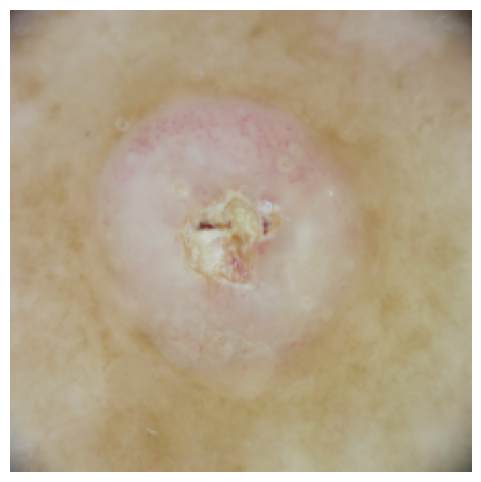

In [96]:
%matplotlib inline
fig_test_img=output_path+'fig_test_img.pdf'
fig=plt.figure(figsize=(6,6))
imgplot=plt.imshow(sample_test_img[img_idx].astype('uint8'))
plt.axis('off')
plt.show()
fig.savefig(fig_test_img, format='pdf', bbox_inches='tight')

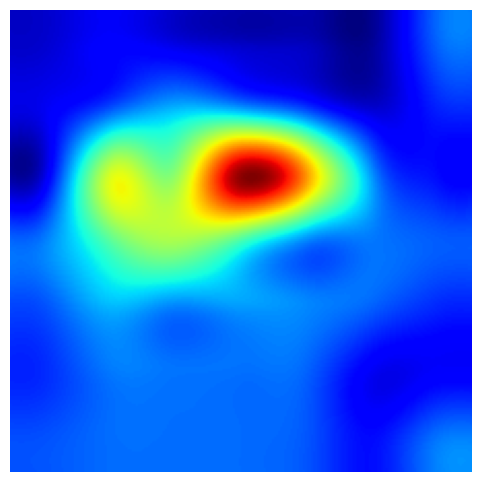

In [97]:
fig_heatmap=output_path+'fig_heatmap.pdf'
fig=plt.figure(figsize=(6,6))
#plt.imshow(sample_test_img[img_idx].astype('uint8'),alpha=1.0)
plt.imshow(cv2.resize(sum_attnmap,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_CUBIC),cmap='jet',alpha=1.0)
plt.axis('off')
plt.show()
fig.savefig(fig_heatmap, format='pdf', bbox_inches='tight')

# Model Plot

In [98]:
tf.keras.utils.plot_model(model, to_file=output_path+'model.pdf', 
    show_shapes=True,    
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=1200,
    layer_range=None,
    show_layer_activations=True,
)

# Move temp to saved_models

In [99]:
from pytz import timezone 
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + '_' + savedfilename + end 
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [100]:
print(dest)

Results/classification2/2.ISIC2019/Fold1/21-08-2025-11-52-54_epochs_40_test_acc_75.05_ISIC2019_classification_Sel_Aug_Th_0.5
